# Kaggriculture: notes from replay hunting

I started this notebook as a collection of engine notes. It gradually
turned into a record of how I have been changing my own agent: download
the current leaders, work out which moves repeat, turn the repeatable
part into a local agent, and try to beat it from both seats.

That distinction matters. A replay is one match, not source code. The
losing player may be excellent, and the winner may only have had the
favorable seed or market order. I use both sides as evidence and do not
label every losing action as a mistake.

Kaggriculture is a 720-turn, two-player simulation. The leaderboard is a
skill rating based on wins, losses and ties; a larger coin margin does
not directly buy more rating. Local bank totals and ladder rating answer
different questions.

The first half of the notebook records the mechanics and earlier public
strategy families. Section 4 is the working diary: c14, Hamburger's
market-timing idea, c15/c16, the multi-leader refresh that produced
c18, and the public-notebook ablation that produced c27.

### Public work I used

| Author / notebook | What I took from it |
| --- | --- |
| [Bovard — Getting Started](https://www.kaggle.com/code/bovard/kaggriculture-getting-started) | Agent contract |
| [Georgy Mamarin — Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays) | Mechanics and market charts |
| [Roman Rozen — Barnyard Economist](https://www.kaggle.com/code/romanrozen/strong-statr-baseline-agent-lb-950) | Melon timing and job-value framing |
| [Roman Tamrazov — Hamburger](https://www.kaggle.com/code/romantamrazov/kaggriculture-hamburger) | Staged mixed herds and clone-aware market timing |
| [Pilkwang Kim — Scenario-Aware](https://www.kaggle.com/code/pilkwang/kaggriculture-scenario-aware-economic-policy) | Economic scheduler lineage |
| [Kun Zhang — C03/C04/C05](https://www.kaggle.com/code/beicicc/kaggriculture-c05-mid-herd-10) | Herd target experiments |
| [prvsiyan — Frontier Lab](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-lab-high-score-visuals) | Cross-play gates |
| Public leaderboard replays | Repeated schedules, opponent responses and market timing |

The notebook embeds the exact candidate used in the final local gate.
Running it creates `main.py` and `submission.tar.gz`; it does not upload
anything by itself.


## 0. Setup

Uses the competition environment from `kaggle-environments` (see the competition data kit `AGENTS.md` / `README.md`).


In [14]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    installed_ke = version("kaggle-environments")
except PackageNotFoundError:
    installed_ke = "0"

# Kaggle's base notebook image may lag the competition runner. The replay-tape
# policies in this notebook require the current Kaggriculture mechanics.
if tuple(map(int, installed_ke.split(".")[:3])) < (1, 32, 2):
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-U", "kaggle-environments>=1.32.2"
    ])

import kaggle_environments
print("kaggle-environments", kaggle_environments.__version__)

from kaggle_environments import make

BOARD, DAYS, TURNS_PER_DAY = 10, 30, 24
EPISODE_STEPS = DAYS * TURNS_PER_DAY  # 720
STARTING_MONEY = 3000


kaggle-environments 1.32.3


## 1. The game in one screen

| Knob | Default | Why it matters |
| --- | ---: | --- |
| Turns | 720 (30 x 24) | Long-horizon capital plan |
| Start cash | $3000 | Opening buys compete with each other |
| Land | NE $1k, SW $2k, SE $4k | Top public leaders almost always take **NE+SW**, rarely SE |
| Hire cost | fib(n) per extra hand **today** | First ~10 hands are cheap; 12+ gets expensive fast |
| Shed | 100 non-seed items | Overflow is destroyed — you must sell / liquidate |
| Win | Most **bank** coins | Unsold inventory does **not** count |
| Ladder | Skill rating | **Only** W/L/T; coin margin is irrelevant for Elo |

### Action economy beats the crop table

Each unit (farmer + hired hands) gets **one field op per turn**.  
A high-margin crop that costs two extra walks often loses to a weaker crop next to the shed.

**Rule of thumb:** hiring about 10 hands costs roughly **$143 for a full day** of parallelism. Under-hiring early is usually more expensive than over-hiring inside the cheap Fibonacci region.


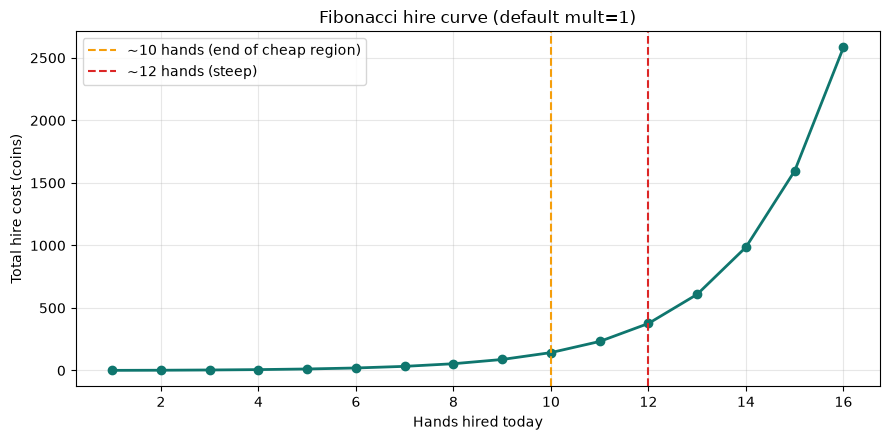

,hands,day_cost
5,6,20
7,8,54
9,10,143
10,11,232
11,12,376
13,14,986


In [15]:
def fib(n):
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return a


def hire_day_cost(n_hands):
    # total cost to hire n hands starting from 0 hires today (mult = 1)
    return sum(fib(i) for i in range(n_hands))


ns = np.arange(1, 17)
costs = [hire_day_cost(int(n)) for n in ns]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ns, costs, "o-", lw=2, color="#0f766e")
ax.axvline(10, color="#f59e0b", ls="--", label="~10 hands (end of cheap region)")
ax.axvline(12, color="#dc2626", ls="--", label="~12 hands (steep)")
ax.set(
    xlabel="Hands hired today",
    ylabel="Total hire cost (coins)",
    title="Fibonacci hire curve (default mult=1)",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({"hands": ns, "day_cost": costs}).query("hands in [6, 8, 10, 11, 12, 14]")


## 2. Engine details that separate weak agents from strong ones

### 2.1 Melon yield window (trust the engine, not only the overview table)

For one-time crops, watering during a bonus window adds yield immediately:

- Melon `max_yield_day = 12` implies window start `ceil(12/2) = 6` → ages **6..12**
- A melon starts at `yield_units = 1`
- Each watered day in-window: **+1** (or **+2** if fertilized)
- Cap is **6**, so full water reaches max around **age 10**, not 12

**16 tiles x 6 = 96 melons** when execution is perfect.  
Missing water on days 6-10 is a common silent leak (for example ~70 units instead of ~96).

### 2.2 `SELL` only sees the shed

- `HARVEST` puts items into the **unit inventory**
- `SELL` spends items from the **shed**

If you harvest 90 melons and never `DROP` while shed-adjacent, the market may not see them until end-of-day auto-drop — often **too late** to fund same-turn land / animal buys.

### 2.3 Fertilizer can be sold

Competition text emphasizes buying fertilizer; the engine's generic `SELL` path still accepts it.  
Each animal generates fertilizer daily → a real sidecar income stream until the market is flooded.

### 2.4 Ladder scoring

Rating updates from **win / loss / tie only**.  
A 140k bank that loses still loses rating. Local mean bank vs `starter` is a useful filter, not the objective.


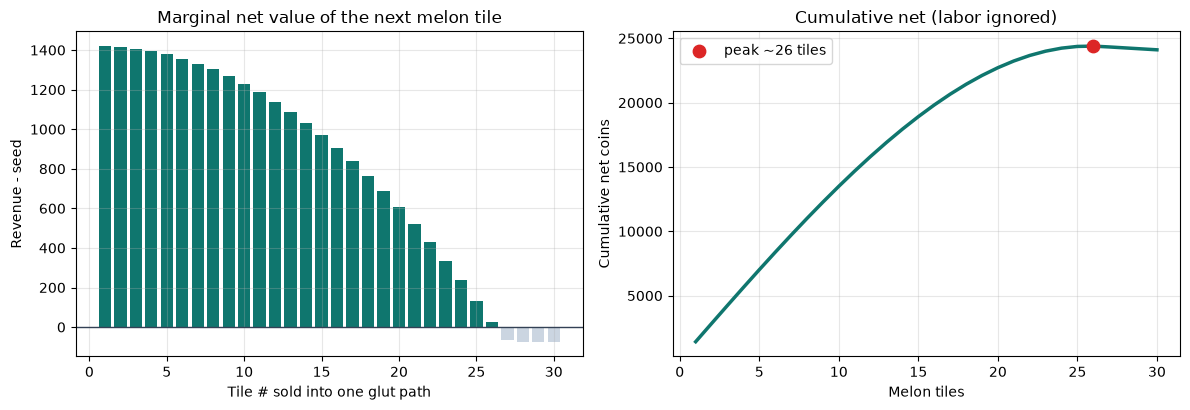

{'illustrative_peak_tiles': 26, 'note': 'Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.'}


In [16]:
# Illustrative melon glut curve (public MARKET_PARAMS style, glut side only)
I0, BASE, T = 10000, 250, 300
above_target = 3.6  # melon above_target


def melon_price(inv):
    x = max(0.0, inv - I0)
    amp = above_target * BASE / (T ** 2)
    return max(1, int(round(BASE - amp * x * x)))


units_per_tile = 6
tiles = np.arange(1, 31)
marginal = []
inv = I0
for t in tiles:
    rev = 0
    for _ in range(units_per_tile):
        p = melon_price(inv)
        rev += p
        if p > 1:
            inv += 1
    marginal.append(rev - 80)  # minus seed cost

cum = np.cumsum(marginal)
best = int(tiles[np.argmax(cum)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(tiles, marginal, color=["#0f766e" if v > 0 else "#cbd5e1" for v in marginal])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(
    title="Marginal net value of the next melon tile",
    xlabel="Tile # sold into one glut path",
    ylabel="Revenue - seed",
)
axes[1].plot(tiles, cum, lw=2.5, color="#0f766e")
axes[1].scatter([best], [cum[best - 1]], s=80, color="#dc2626", zorder=3, label=f"peak ~{best} tiles")
axes[1].set(title="Cumulative net (labor ignored)", xlabel="Melon tiles", ylabel="Cumulative net coins")
axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print({
    "illustrative_peak_tiles": best,
    "note": "Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.",
})


## 3. Strategy clusters in the public meta

| Cluster | Opening | Peak farm | Strengths | Failure mode |
| --- | --- | --- | --- | --- |
| **A. Pure cow ranch** | 3-10 cows, little crop | ~10 cows, often NE only | Punishes soft / crop-only bots | Milk wars collapse banks; coin-flip H2H |
| **B. Melon IPO** | 16 melons + 2 cows | Day-10 dump to 12c+8s and 3 quads | Huge capital spike when uncontested | Second melon dumper hits the $1 floor |
| **C. Staged economic herd (C0x)** | **3 cows + 1 sheep** floor | Stages **4 to 8/10 to 14/15** | Strongest *public code* family | Everyone forks it → correlated losses |
| **D. Adaptive leader style** | 3c+1s, ~6 melons | Dynamic cow/sheep/goose mix | Rebalances when milk is contested | Harder to clone cleanly |
| **E. Stable efficiency tape** | Repeated elite trajectory | Tight 8c/6s production and labor schedule | Reproducible across opponents; current best live result | Can become correlated if widely copied |

### Approximate local strength ordering (sandbox H2H)

```text
starter << pure cow << melon IPO << C03 << C05 << Radiant routers << c11/c12/c13 << c14
```

**Caveat:** a bot that prints 100k-170k vs `starter` can still sit mid-ladder, because ladder opponents are other strong farms.


## 4. Replay diary: from c14 to the current multi-leader market meta

### 4.1 The first useful replay rule

My first mistake was treating the winner's tape as the target. That is
too noisy. I now look for three things before copying anything:

1. Does the same field schedule appear against several opponents?
2. Is the market schedule also stable, or is it reacting to the match?
3. Does the distilled tape beat the previous agent from both seats?

The earlier senkin13 refresh passed that test unusually cleanly: the
exact 720-turn field and market schedule appeared in five games. It
ended near 8 cows, 6 sheep and 7 strawberry plots, and became c14 after
I added an observation-driven final-eight-turn cleanup routine.

c14 beat c11, c12 and c13 27-3 each in the paired-seat gate and reached
2182.2 on its standalone ladder run. That was the point where replay
stability became more useful to me than selecting a spectacular single
score.


### 4.2 Hamburger changed the question from *what to build* to *when to sell*

The newer Hamburger notebook did not discover a radically different
mature farm. Its best branch, `Clone Quad H1`, checks whether the two
public farms remain nearly identical. After two close checkpoints it
looks one turn ahead in its own schedule and sells one available
premium line—melon, strawberry, milk or wool—before the expected
shared-market dump.

That is a small wrapper with a large mirror-match effect. Hamburger
reported 6-0 against its anchor, with a mean margin of +1,865.7. I
moved the same one-turn front-run onto the stronger refreshed Senkin
schedule. That hybrid became c15.


In [17]:
c15_gate = pd.DataFrame([
    ["raw refreshed Senkin", 14, 2, 0, 2249.8],
    ["Vlad stable", 9, 7, 0, 725.5],
    ["Hamburger Clone Quad H1", 16, 0, 0, 2083.9],
    ["c14", 16, 0, 0, 2300.2],
    ["Batuhan rank-one replay", 12, 0, 0, 2538.3],
    ["Chloe common tape", 12, 0, 0, 2431.1],
    ["Kenmatsu anchor", 12, 0, 0, 2735.2],
], columns=["opponent", "wins", "losses", "ties", "mean_margin"])
c15_gate


,opponent,wins,losses,ties,mean_margin
0,raw refreshed Senkin,14,2,0,2249.8
1,Vlad stable,9,7,0,725.5
2,Hamburger Clone Quad H1,16,0,0,2083.9
3,c14,16,0,0,2300.2
4,Batuhan rank-one replay,12,0,0,2538.3
5,Chloe common tape,12,0,0,2431.1
6,Kenmatsu anchor,12,0,0,2735.2


The important row is the first one. c15 went 14-2 against the same
refreshed Senkin tape without the wrapper. That convinced me the
timing rule was doing real work rather than merely decorating a
stronger base.

### 4.3 Refreshing the leaders—and catching my own downloader mistake

On 3 August I pulled five replays for each displayed top-five team:

```bash
python scripts/download_top_replays.py --top 5 --per-team 5 \
    --leader-submission-only --force
```

The `--leader-submission-only` part was added after a bad first pass.
Simulation teams can have two active submissions. My original script
merged both episode lists and picked the newest games, which sampled
Tran H Hoang's and Knight of Favonius's newer *lower-rated* agents,
not the submissions responsible for their displayed leaderboard
scores. The corrected run matches `publicScore` to the displayed team
score before choosing episodes.

The leaderboard moved while I was doing this, so the numbers below
are a timestamped snapshot, not permanent ranks.


In [18]:
replay_snapshot = pd.DataFrame([
    [1, "Tran H Hoang", 2858.3, 55203154, 5, 5, "5-0-0", "8c/5s, 5 strawberry, 12 hands"],
    [2, "Knight of Favonius", 2778.8, 55208294, 4, 4, "3-2-0", "8c/5s, 5 strawberry, 12 hands"],
    [3, "VN-Orion", 2735.3, 55207137, 1, 1, "4-1-0", "8c/5s, 5 strawberry, 12 hands"],
    [4, "Superallen001", 2717.9, 55207089, 1, 1, "2-3-0", "8c/5s, 4-5 strawberry, 12 hands"],
    [5, "ömer kiraz", 2700.9, 55210461, 3, 3, "4-0-1", "8c/5s, 5 strawberry, 12 hands"],
], columns=[
    "rank", "team", "rating", "submission_id", "field_variants",
    "market_variants", "sample_record", "mature_farm",
])
replay_snapshot


,rank,team,rating,submission_id,field_variants,market_variants,sample_record,mature_farm
0,1,Tran H Hoang,2858.3,55203154,5,5,5-0-0,"8c/5s, 5 strawberry, 12 hands"
1,2,Knight of Favonius,2778.8,55208294,4,4,3-2-0,"8c/5s, 5 strawberry, 12 hands"
2,3,VN-Orion,2735.3,55207137,1,1,4-1-0,"8c/5s, 5 strawberry, 12 hands"
3,4,Superallen001,2717.9,55207089,1,1,2-3-0,"8c/5s, 4-5 strawberry, 12 hands"
4,5,ömer kiraz,2700.9,55210461,3,3,4-0-1,"8c/5s, 5 strawberry, 12 hands"


The striking result was not one clever move. It was convergence.
All five teams were using versions of the same 8-cow/5-sheep,
12-hand, three-quadrant plan. Many tapes from different teams differed
on only 2-5 field turns and 2-6 market turns. By contrast, this family
differed from c15 on about 226 field turns and 402 market turns.

Tran and Knight had several variants, so I did not use their highest
scoring replay as the new base. VN-Orion repeated one exact full tape
in all five games. Superallen also repeated one tape, and the two
stable versions are only four field turns and three market turns
apart. VN-Orion was the cleaner source for a standalone test.

I kept c15's clone-aware premium front-run and terminal cleanup, but
replaced its base schedule with the stable VN-Orion tape. That is the
c16 candidate below.


In [19]:
c16_gate = pd.DataFrame([
    ["c15", 14, 2, 0],
    ["Hamburger Clone Quad H1", 15, 1, 0],
    ["c14", 11, 1, 0],
    ["Vlad stable", 11, 1, 0],
    ["refreshed Senkin", 11, 1, 0],
    ["Batuhan rank-one replay", 11, 1, 0],
    ["Superallen common-meta tape", 7, 7, 2],
], columns=["opponent", "wins", "losses", "ties"])
c16_gate


,opponent,wins,losses,ties
0,c15,14,2,0
1,Hamburger Clone Quad H1,15,1,0
2,c14,11,1,0
3,Vlad stable,11,1,0
4,refreshed Senkin,11,1,0
5,Batuhan rank-one replay,11,1,0
6,Superallen common-meta tape,7,7,2


The 7-7-2 control is reassuring rather than disappointing: the two
independently sampled common-meta tapes behave like the same policy.
Against the previous families, the new schedule has a clear edge.

### 4.4 Why identical uploads can show very different ratings

I also chased what looked like a packaging bug. The standalone c14
scored 2182.2, while a notebook-produced c14 initially showed 1210.1.
I downloaded the notebook's actual server artifact and compared it
byte for byte. Both `main.py` files had SHA-256
`569cf2d20e3b37c3805c2a4ca7c4e5728eaa85df85c78392cdc3df77c5ddc17b`.

They really were the same agent. Kaggle had simply created a new
rating instance. The standalone copy accumulated 89 public games;
notebook v9 had 26 before it was displaced. While I was checking,
v9 moved from 1210.1 to 1865.6 without a code change. Early opponents,
seeds and seats can put identical copies on very different rating
paths, and only the latest two team submissions continue receiving
games.


### 4.5 A ten-team refresh: the farm stayed fixed, the market moved

The next leaderboard snapshot had Ueddy first at 2847.0 and Tran H
Hoang second at 2821.9. I downloaded 12 public episodes for each of
the top ten teams, restricted to each score-matching active
submission: 120 replay selections in total.

The top ten had converged even more tightly than before. Almost all
mature farms ended near 8 cows, 6 sheep, 3 quadrants and 12 hands,
with 21 melon seeds and 44 strawberry seeds. The useful divergence
was market execution. Ueddy kept the same supply chain but scheduled
materially more premium liquidation than c16.

I distilled all 12 Ueddy traces with the same controller and screened
each against c16. Eleven swept the first 4-game paired-seat gate.
Episode `89746553`, player 1, had the strongest screen margin and
became c18.


In [20]:
premium_sales = pd.DataFrame([
    ["MELON", 146, 172],
    ["MILK", 360, 472],
    ["STRAWBERRY", 394, 505],
    ["WOOL", 241, 297],
], columns=["item", "c16_attempted_sales", "c18_attempted_sales"])

c18_gate = pd.DataFrame([
    ["c11", 10, 0, 14269.7],
    ["c12", 9, 1, 11128.0],
    ["c13", 9, 1, 10654.1],
    ["c14", 9, 1, 6263.7],
    ["c15", 7, 3, 2339.4],
    ["c16", 9, 1, 2794.4],
    ["c17", 9, 1, 2794.4],
], columns=["opponent", "c18_wins", "losses", "mean_margin"])

display(premium_sales)
c18_gate


,item,c16_attempted_sales,c18_attempted_sales
0,MELON,146,172
1,MILK,360,472
2,STRAWBERRY,394,505
3,WOOL,241,297


,opponent,c18_wins,losses,mean_margin
0,c11,10,0,14269.7
1,c12,9,1,11128.0
2,c13,9,1,10654.1
3,c14,9,1,6263.7
4,c15,7,3,2339.4
5,c16,9,1,2794.4
6,c17,9,1,2794.4


The extended c16 gate finished **35-5** over 20 seeds and both
seats, with a +3,161.3 mean margin and no errors. Representative
tapes from the other refreshed leaders were also screened directly.
Anton's was the only close challenger; c18 won their extended
20-seed match 23-17, so c18 was preferred for head-to-head
reliability.

c18 changes only 20 pre-terminal field turns from c16 but 112 market
turns. This is the clearest evidence in the diary that the current
edge comes from inventory-sale timing rather than another change in
herd composition.


### 4.6 Three public notebooks and one terminal-timing correction

I then compared three newer public notebooks directly:

- Navaz's notebook restores Tran H Hoang episode `89674601`;
- Hamburger V27 uses that exact same source as its anchor and tests
  SELL-slot ordering plus terminal inventory relays;
- Kaito V18 selects complete market experts once per day using
  public-state distance, seat priors and hysteresis.

Navaz/Tran and Hamburger's anchor have the same SHA-256, so they are
one base strategy rather than two independent confirmations. Kaito
was the strongest import and beat c20, Navaz and Hamburger 18-2
each, but c17 still beat Kaito 17-3.

Field/market swaps were informative but did not promote. Kaito's
field with c17's market was competitive, while Kaito's market on a
mismatched field was weaker. A seat router also remained just below
c17. The transferable Hamburger finding was more mechanical: step
718 executes, while action index 719 does not.

c17's terminal field controller had taken over at step 712. Delaying
it to 717 preserves five more turns of the locally stronger tape and
still leaves steps 717 and 718 for terminal cleanup. This one-line
correction became c27.


In [21]:
c27_gate = pd.DataFrame([
    ["c17 Market Common", 13, 7, 0, 42.0],
    ["c20 Rank-One Medoid", 20, 0, 0, 5226.8],
    ["Navaz / Tran 89674601", 19, 1, 0, 3558.9],
    ["Kaito V18 Closed Loop", 19, 1, 0, 3559.8],
    ["Hamburger V27 experimental", 19, 1, 0, 4157.1],
], columns=["opponent", "c27_wins", "losses", "ties", "mean_margin"])
c27_gate


,opponent,c27_wins,losses,ties,mean_margin
0,c17 Market Common,13,7,0,42.0
1,c20 Rank-One Medoid,20,0,0,5226.8
2,Navaz / Tran 89674601,19,1,0,3558.9
3,Kaito V18 Closed Loop,19,1,0,3559.8
4,Hamburger V27 experimental,19,1,0,4157.1


The fresh promotion gate finished **90-10**, using ten untouched
seeds, both seats and the official 1.32.2 engine, with no runtime
errors. This remains local evidence rather than a leaderboard-score
claim. More importantly, it came from a falsifiable engine detail
and survived direct comparison with the previous best.


In [22]:
openings = pd.DataFrame([
    {"name": "Pure cow open", "melon_seeds": 0, "cows": 3, "sheep": 0, "notes": "expand cows later"},
    {"name": "Melon IPO open", "melon_seeds": 16, "cows": 2, "sheep": 0, "notes": "dump around day 10"},
    {"name": "C0x / radiant open", "melon_seeds": 6, "cows": 3, "sheep": 1, "notes": "mixed option value"},
    {"name": "Nishchal-like open", "melon_seeds": 9, "cows": 4, "sheep": 0, "notes": "early dairy density"},
])
openings["seed_cost"] = openings.melon_seeds * 80
openings["animal_cost"] = openings.cows * 400 + openings.sheep * 500
openings["rough_spend"] = openings.seed_cost + openings.animal_cost
openings["cash_left_from_3000"] = STARTING_MONEY - openings.rough_spend
openings


,name,melon_seeds,cows,sheep,notes,seed_cost,animal_cost,rough_spend,cash_left_from_3000
0,Pure cow open,0,3,0,expand cows later,0,1200,1200,1800
1,Melon IPO open,16,2,0,dump around day 10,1280,800,2080,920
2,C0x / radiant open,6,3,1,mixed option value,480,1700,2180,820
3,Nishchal-like open,9,4,0,early dairy density,720,1600,2320,680


## 5. Live mini-simulations

### 5.1 Environment smoke test


In [23]:
def run_pair(a="starter", b="starter", seed=0, steps=720):
    env = make("kaggriculture", configuration={"episodeSteps": steps, "seed": seed}, debug=False)
    env.run([a, b])
    final = env.steps[-1]
    return {
        "seed": seed,
        "r0": final[0].reward,
        "r1": final[1].reward,
        "s0": str(final[0].status),
        "s1": str(final[1].status),
    }

pd.DataFrame([run_pair("starter", "random", seed=s) for s in range(3)])


,seed,r0,r1,s0,s1
0,0,3510.0,620.0,DONE,DONE
1,1,3491.0,0.0,DONE,DONE
2,2,3485.0,0.0,DONE,DONE


### 5.2 Built-in baseline matrix

Expect `starter` to beat `random` and `pass` on average. Your bot should crush `starter` locally before you overfit the public leaderboard number.


In [24]:
rows = []
for a, b in [("starter", "random"), ("starter", "pass"), ("random", "pass")]:
    for seed in range(2):
        rows.append({"a": a, "b": b, **run_pair(a, b, seed=seed)})
pd.DataFrame(rows)


,a,b,seed,r0,r1,s0,s1
0,starter,random,0,3487.0,0.0,DONE,DONE
1,starter,random,1,3503.0,0.0,DONE,DONE
2,starter,pass,0,3509.0,3000.0,DONE,DONE
3,starter,pass,1,3491.0,3000.0,DONE,DONE
4,random,pass,0,0.0,3000.0,DONE,DONE
5,random,pass,1,0.0,3000.0,DONE,DONE


## 6. The build ladder I actually followed

I began with agents that merely survived validation, then moved through
pure cows, a melon capital event, staged mixed herds and public tape
routers. The last four steps mattered most:

- **c14:** choose a full schedule only after it repeats across opponents;
- **c15:** keep the schedule but front-run a clone's premium sale by one turn;
- **c16:** refresh the base when several leaders converge on a demonstrably
  stronger operating plan.
- **c18:** hold the common farm fixed and promote the premium market
  schedule that survives a ten-team replay screen.
- **c27:** preserve c17's strong market route but move terminal field
  control from step 712 to the verified final window at step 717.

Every promotion used both seats. I keep the previous agent as an opponent
and add at least one unrelated public family. A high bank against
`starter` is a smoke test, not a promotion test.


## 7. Common bugs (high frequency)

| Bug | Symptom | Fix |
| --- | --- | --- |
| CARE ranked above melon WATER | Day 9 waters only part of the field; yield ~70 not ~96 | Water priority first in ages 6-12 |
| No DROP after HARVEST | Produce stuck in unit inventory; IPO underfunded | DROP when carrying melon/milk stacks |
| Dig melon tiles for pastures too early | Destroy fruit before harvest | Protect valuable melons until sold |
| Buy many cows day 0 with no feed reserve | Animals escape by day 2 | Reserve wheat cash before animal spam |
| Fixed 10 cows forever | Mirror banks collapse toward ~40k | Add sheep/strawberry/opponent routing |
| Optimize only mean bank vs starter | High local bank, mediocre Elo | H2H vs strong bots, both seats |
| Two near-identical active submits | Meta shift kills both | Diversify the second slot |


## 8. Local evaluation protocol

```text
1. Compile/import the exact packaged main.py
2. Self-play validation: both agents must finish DONE
3. Play the previous best on several seeds, both seats
4. Play at least one different public family
5. Include a near-mirror control when the meta has converged
6. Keep the result files, including losses
7. Only then build an archive
```

Shared-market games are not symmetric. A one-seat test can reverse the
apparent winner.


In [25]:
def h2h(agent_a, agent_b, seeds=range(3), both_seats=True):
    """Quick head-to-head helper. agent_* may be callables or built-in names."""
    seats = (0, 1) if both_seats else (0,)
    rows = []
    for seed in seeds:
        for seat in seats:
            env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": int(seed)})
            order = [agent_a, agent_b] if seat == 0 else [agent_b, agent_a]
            env.run(order)
            final = env.steps[-1]
            r0, r1 = final[0].reward, final[1].reward
            me, opp = (r0, r1) if seat == 0 else (r1, r0)
            rows.append({
                "seed": seed,
                "seat": seat,
                "me": me,
                "opp": opp,
                "win": me > opp,
                "status0": str(final[0].status),
                "status1": str(final[1].status),
            })
    df = pd.DataFrame(rows)
    summary = {
        "games": len(df),
        "wins": int(df.win.sum()),
        "win_rate": float(df.win.mean()),
        "mean_bank": float(df.me.mean()),
        "mean_opp": float(df.opp.mean()),
    }
    return df, summary


# Example using built-ins only (swap in your agent callables locally)
df, summary = h2h("starter", "random", seeds=range(2))
print(summary)
df


{'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_bank': 3500.0, 'mean_opp': 32.5}


,seed,seat,me,opp,win,status0,status1
0,0,0,3503.0,30.0,True,DONE,DONE
1,0,1,3501.0,60.0,True,DONE,DONE
2,1,0,3496.0,40.0,True,DONE,DONE
3,1,1,3500.0,0.0,True,DONE,DONE


## 9. The strategy history in one line

```text
melon tutorials -> cow ranches -> staged mixed herds -> economic schedulers
  -> larger target herds -> tape routers -> stable c14 efficiency schedule
    -> c15 clone-aware sale timing -> c16 common-meta schedule
      -> c18 rank-one premium-liquidation schedule
        -> c17 refreshed market-common tape -> c27 terminal-717 correction
```

The endpoint alone never explained the full gain. c14 improved labor and
inventory timing. c15 exploited market order in mirror games. c16 changed
hundreds of turns while actually using one fewer sheep: the current
leaders are buying more labor and coordinating the whole route, not just
maximizing animal count. c18 then changes almost no field structure but
more than one hundred market turns. c27 changes no economic policy at
all; it corrects when the terminal controller is allowed to replace the
proven field tape.


## 10. Checklist before building the next archive

- [ ] Validation self-play ends `DONE` / `DONE`
- [ ] Harvested goods are dropped before a planned sale
- [ ] Final shed inventory is liquidated
- [ ] The replay source repeats across several opponents
- [ ] The selected replay belongs to the leaderboard-scoring submission,
  not merely the team's newest active submission
- [ ] Both seats were tested against the previous best
- [ ] A near-mirror control was included
- [ ] Losses were inspected instead of removed as “bad demonstrations”
- [ ] The exact packaged `main.py` was imported in the smoke test


## 11. Where I would look next

The field plan has become highly correlated, so another herd-layout copy
is unlikely to help. The useful remaining questions are inventory-aware
sale sizing, clone ordering, and whether Anton's higher-variance market
route can be gated from observable scenario state.

For now, c27 is the stopping point. It went 90-10 in the fresh
public-policy gate, including 13-7 directly against c17. The next useful
experiment should refresh chronological top-team replays and test
inventory-aware market actions after more state is observable, rather
than selecting an entire route at turn one.


## 12. Exact c27 artifact used for the local gate

This cell embeds the exact `c27_c17_terminal717` source, writes it to
`/kaggle/working/main.py`, packages `submission.tar.gz`, imports that
generated file and runs a smoke game.

| Field | Value |
| --- | --- |
| Base policy | c17 Market Common |
| Economic route | automatylicza episode `89827371`, player 0 |
| Main change | terminal field handoff moved from step 712 to 717 |
| Preserved controller | clone-aware premium timing + terminal liquidation |
| Fresh public-policy gate | 90-10 over ten seeds and both seats |
| Direct result vs c17 | 13-7 |
| Ladder status | not submitted from this notebook |

Building the archive is deliberately separate from uploading it.


In [ ]:
import base64
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()

MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

# Exact c27 source from the local gate, compressed so the notebook stays readable.
_AGENT_B64_PARTS = [
    "eNqtfGmbokiz6Pf5FUW7HNBmXlxwGRHFDUEEwd15RgVBQRGQTXH77Retpat6euace+6tL5KZEZGRsUdS+u3bt1Uq/8eLraxtxVEV"
    "+aUAr8zjf1A4HCjWf3Kw49riUVJsO3hZmfu9abysNUWXXyxdNF6Omqu+uKryEkKZxkZx3BfdXIm6Hry44SAktxftneK+OKuQtqcr"
    "v3/79u03bW+ZtvsiiY6Sy76PVqYVvD9vHdN4fz7rmvTbb4uBQNSbL+Xn0u+6KcoO+Fj5XVZCrqyQdwd8pfe7VEAfk7IC/vYS/v3X"
    "CrZ3WGy8Nq7ihYlIeEwpcTa6rx5WtdmuO16aw+aoY59rabJ48jZHTKuZKb1L9w78NkN6C2ycjCyPUGVVVMd9p37UjuWNIyzJTABX"
    "pEN3ccEOEHmZXw567xC/nKxuPsVe7C10XzItuFzpW/3x5ZJXiMu8u7xeDig4jB/1RODhdE8DyV40N882OmBn6kzxxRCP9hbDysQ4"
    "WpLZvZQb+cy1682U5KEynE3Y6BWMkuIKPd7PotKZZNLe1rfKw+6lEbkPS3q/MPOCRV/J03oupozIlgLBWNOK7gpOZYo6zfNhu7he"
    "dMO3J3TWqC+NefReXGYXrExee0y/WUC9dVYrOLhCbul1remp811qXKxwwypz7UqJoVUlgNuQNLkD3IU9SsHhi67kbW1dWqKdeIVK"
    "zmZANE2PJXpo5RYq4ljHyK0L1xqFYsccwXfrsrx7LW4prQXrCNXzx7NfT9S6MFbtb1okoFrLqF2GnXFzOx/G2kRzjRzlBMaTpd4w"
    "bnT3V2Q1mFiJpu0fJsWoyXfR6dG6juBiLbgDrrjWEudlb5UPCgej5FuCvkGBplgZ4m07XpryS8ARvAzaTKRzzaV83RBNpDqdEMLB"
    "RopB3ZlFB6hYuSH83I8gHblQYYBjwwsy8QYmnpzlYhIeVmvNU+xu0KnE6R3tq6u+JClbBjj3ju2CEwCkjSZ33mLewYuJ3owtLDoA"
    "XcM8t1TGE4mIQOI5y172etp5AhC6EtojgvtzKj9I+Rh57NQpLGqqYq6RNMeaZM+CTe6anp9ZnD3C+e05UZr6l8R2Zq7rMOB39slG"
    "drL32OlagTJiFt1dohESV8ftFatiAMCxCLGmVzTV3ydOu5l3KeN7az4li+fxqrGocMU4O8k341AJLSTzneQy3oOmaKolJukc1bRm"
    "sfoOW9QrlNKs43fnGESsaG13qPrBAK21T7m4jtEzeqnpCNbw+wzvjLDTVl7A7mFWg5doF4L0MsQJ8j4NzVE5FyEuqgmyzToE9K0j"
    "oPo99JaFHH63ZXntBuxbdVNbaPRqRiHVNT69mdsmXqI9/HIb50rRjAaZoyTWygvsouQs08Eca9z62SUgqeKhv8lY+HibGAyQCBOt"
    "g81ZT8U0vZ/1NuKksdLsqJC72EcAz3WwDukECQauFhfnRK5bLuYqtVVOZMblu58p5VP5uHUcRtdYv1B0W0yzXpm2zVWtGJlWD4MM"
    "vAOFxGgiT6qKuC/uEr0tYHpcqlGsR9pjNehUt+4KWVwypTmWPdx2tTjRTe3L+dLWTTSA86IYt4YMPu+dIUFfCkLrwqQrsxh6RpW1"
    "HFmt4So5bFtcb1XsXYHyji5J0sVMSulG92SRh4NT2eU79cgwoHLRIJqkh3ZsOl7lZ7vhTODPBbpk1SM5t31N7Ab95mmuXyqSXNIy"
    "KlZQz+n0GHcS8fFJakQSQGmj0Js5G6AlKLYdyQwPjQ+NtNQWVlidBkyXbGYuSywDzUetbf6azg4nxKp4Jrz8xh8S10kY0txCemgY"
    "g8FwpI+R4mGRKGkHHV+hc0G6BqlSZd45Navi2TlwGbwrrlrl65oA61bcNKIx2QqSYHWUlcxd8nCE0Y13MRvnMXO40WsgJowrbUEm"
    "K5zqN4gUqXN3MEfZZDx+sgu42peJbgXv43471cVFOp66LAa7O7PnNKGUK01LyuRMg4k4R7NRJnqN0GhyX6Tb+1XK4EPBJtZ5NGdO"
    "QYq7OPG23vfgcQmU8zowrPVXtXnfLE3HGk9vdAwrHi86sJBS8BhR8oWazUTJrhjFlAmCzGTulgylOC8BPYY5HNBrbbJtqATUbutj"
    "CHWKEyLAz3LqFLsu6r0WdZjGyge3udkRgXVfqxw6hJvJVloe8dtTsldeEq1Lu4M5KR1uF7AbkaApgG+45TSVMJfwlC/mc23cLqam"
    "QXe5ivSS02JmR6Zn9ymSu0/4XmXtJ1vMNh/JArDJ8UmaTWSTAOtKgISD9KLiIdS0Ze5GYNaGMmut6YrEtOmBN2xY6swBDx6NoJYx"
    "rLLWMVWnvLVFeYe8qqGusV60mUhqzlkQc8Ekc+pPV5nhDWYjZbqf14cHOBXZtwd5uuNXs8g66pswClbxaQ7NGsdCTb2nja7JXdbG"
    "fDZZQ5dMF+PoMM9m4yg41UE3UaxvFZ2WtN16xWTKRJztjWKXU38TQygpczyn+yJeRIY1bUglLLFZGNy1ZWk2IkrNEYG09AIoGFZ0"
    "eJpv2wMPMQeJU3eY5IpaGBTr4yWeQ1aakJ4XFcmeS0sNAgaA2g+YUmxZruvrIqOlMLB23C/Hin9a8ddsfVWP8ah6tObFtLZCr9Nx"
    "1BctadqT2hficruz6moQ5NKnZltl4gN5foJOSxLoHbzlBJNnK7R7UPHMaWk2pj5Dm3vbuFmzynWkwNnitIht6gbkLpGLC58sWavQ"
    "1ZQw00qxMM75LaKb79+HA8x1NuzmMJgtU3v9pqVj2qDNpk/dM9c8TMrpY3PejZhuTN+WODYe7U3EExS7J93qZNS1Z0giOs1Ndtcb"
    "08Bntyp2Oa8dnqQps2PVT40DNzzQWrfOYfm07/uji9FtxCr+pFtF150ZFN8RjC5sGJ1j+c6gGrtIgymoLQpWaTZRzXixNTrvRNvR"
    "jEKxn1zXfaZZ9uRFiQkaTA+/x0b7Gr/CYgoQmQumO+lR85ssnDDMkEG20G4h88QKJUoHeGHoOjf3uouRZigDhQH5u9Tp91uB3mVX"
    "w/Q5N7oZCLguxzG02KGMfHwbHbvdqL+k5n6B2EvdIoEgvIskUw165Rl7OE0mEbRjVo7M0EtfcJ7HriJbJIxoJrlaLDsVuijnJmvb"
    "Pac7qwtYThQ31YOslvjZzotEPamd7VUwgZyt9nls1R1qyKkJpr1T7NihbtlNYmLocKuLnzv1y86aA/X0pTzj7frBnKCpYFR2MEAK"
    "bL5ZAYOTMsAGwSUuFs1bXIpR3HFinFrFVsXPjh0RCDZjoHUhhtSWPwaZw3KApFpBVrPZ4FLKqne4f03MkRJbkDfGsp/F805AjXSg"
    "3iLYwWEjq1ayUdaqt3vo2/NbZdqhTgMEdWXnsL1WR2UST9VnWYrdOR1WzLQO/qkoltkUnd3xBb6W7dtB/HrVlvCgl5GC+CXGqnt1"
    "MouPlmJgqFGw5y8Yte5BpQClUt17/4h1hL7EBLJ2pE5DIMZYVETXCu7cqLpyq4vgU6RCwiB/KNj9LRexAYcjhqeZtB5OUp6Qupir"
    "1HysXQvJM2myAX8SS9NZFEtlMpnDLDb00OQpm8vCdLR2FmR/Nyucb/XZrL2/t1UpIR+bSsX2aIU7YmHJFZVr21zCjGfLZiWMbpc9"
    "szLx7GI/wvZg9KzNqkq9vbPSrUsW5sAIdh5m/HRt0TqkClddaNbteXVVSQzOIyeaLVJLYDsjADGQsmBkgLQrcX2aAPH71IOS6wOK"
    "D+BDhleJ7DApUyQZOw92DcYV9wQ5oSkwHxlJZZGuyuc8ygLNM7hJxLOFA+loIBJ1cplitxBLaGVTxvHNtEO4lSzHRVA+6qSppjib"
    "4WJZLZpbiVEWseHFyu+Yyf2+paagqSd9vXaiYksdS0StXsZgrrFEaWy3s/1lfg+Z4HarNgdQ1yqNWXBHjFQuH2kCLb10U6R8a7rE"
    "2/doL83UV60l4fGH3JR34/widkUvhnqAFu0Co0jGAl4ZW2GeTseLaiGeyN3oflqVNm2QyB8w5xAxqHiEneW7pZ1UlSfHbiVY5iyo"
    "nBC34J53s5fK1POhempfoPOIGZ/ao3hZa1LS5sLgyTlU83vt8XnWoAPWNoU2UhkeEqvbdVKentGdZKfH3pWYF/dwQ0f9rDIezTK2"
    "H4tfxnInT/Zj97IrbHp2ezb0mIJKCDhF4kKCNwcXqnY4TqPUwjiTR/C2ambiWDXGx1yYW8/HM1+FungdUSNRxTsHi1hmmKhW7q2r"
    "oVkzAwj4/GLoxQUl1roCGjJWgkM3AJud/M4cy/11Ue9HYhh2nWT3s1Qw9Ed24npd1lKzhpQLa+dkieTSkNGmDwEnDaRGrluNVgIy"
    "e7Uyy3iioupxTtJO/DCKt3kk2lTO4nzDAnHMzeAruxXjqxzUh6ZFR4EDn56MbDkbGjq3PF43yjhNzUfHYS8K9OOz4ooDpBKpIGAL"
    "nnta+8AE22xiMw6WVIybsM3Fdu2tR8VqJ0+vJvqABw5S9uAOBtsU2y4LJylKurrbS+oyiC5ZcywcwHWxL09H032X1LPjHQTy84pN"
    "H1RvuNjftuTstsZXvYXMw4GYUyPtzAzHUHbLidwKMvijYOgVhdzrsxw1PidbqD05U+lYsGlBQL4hgRcLpTL3SRaoNC/jRm+5IKsO"
    "qJ2mXHuHMtYs0o/mjdzaiBzB6F1MFRLRzW4+Xp5OzfXcSIPEoZsdkT5rqwmQrsGxc9ZdjmBgZx20w5EXqsVmzMQkAdOzE2yrwmxU"
    "n4Q9Q4zWK8eYk8FrST/RVRlgmE3HXSUyEcGi5QA1ioh2hAV7aYOt4lREsG272Mvcxqexe3SGc3yjVrqZOjq6MOO0QuloUUPYxiV0"
    "7PSVaiV8rQ8Th2W3L9zLuM1cYpwH9Iw9tIO3zbLl4ju2d3O2YS1r75P5+FhMCFW1Bp5URGyUbtC85S/HxtRaNbbceUDAHeCcj0Zb"
    "q5xZXpaaEtlMKVzu2itybixmjVv7iZH2hXMyD9G05TRZtkzNocI5zsZmxt7w3W2H8DPj7UmdlUCUp50Sc0O76XYLRjaD2gxQRGkf"
    "JAz0WOeldiLcOAcM4162mjbi1pKYEd6pWB9kiMZ1cdqlkZKeBe40FjMjRbkV1hI3bDeWjgehsavtXSqPIX2ZnbkxlmwPIgFNbME0"
    "MrxtLkC3td0EZv9kRCR7XUDyOZJPWJrnD/nepZuvjbN12dqSQLSy22SCVTzZbojrMZHv5qlqDURzuhHvnP1R/2qo4Ckz9goMnT9h"
    "wqCnF7E1yBHT9YBVnFLuOsQqmRk1XLUFh5je1XEKynbFERpWh/5OzETTygZgi+kaKeUjl0JWRXaAQZ1GfpgeK/FTc1PGVvi+e8RI"
    "e++cgUE+1Rbm8wQHbEE+QtPeeDIpIxGpaJ3aZF1l8tPmpV2VmA1wxw5RHuX78DIlsQ2zlRJu+20/ke3BqnfFol2kv5EPscgk2rSy"
    "XrW1puR0j7+XQTsWSEOhxmVXRsxSLCA/ThtMEYsJxZxuMfsWHgiF6MJJ0RNswgt7V8muO2wbjSRIAuzFWTA1JNMu0yryG+AibA+V"
    "qHCZgt1TsKRRd+HNkCY6oCiwu0wkCNjoD3G3EQZkjyeoazqZYbc4uvXl4mrYEiedy2grpG0bGOKb4iybqTNpEek0bpvSOSz4V3cu"
    "X++BPBnX/a0XMIYtj5DdrF33psncgZ0movuLpdXKl0u/z2WnzGXH3JHzvbVW7CshVLJGCpfBkulmvWWtlUABN4f01qiTClwpE2/y"
    "E9oX5GZKQATdNgRX9FjqgsdAqj0gWxs83k7fKWsK7dioGuUb1tCHB3A3BUSza2JUxuZlW7+cRpJeleQ6YQObRj/aVbyOGe8O1xd8"
    "0ilNCbUm59whNA0G6fogb0/P91SMBlMIn2s0QFXQtN5etLKzmeSok5xRvsKXZSp3UHJntkLrm6TXSYmL/Zzqnb1SuXtgb2Y2ECjx"
    "Ur6U1T2Uh0ptTYo5YEvIMD22IKpbKD0wp1y8je/U+hKBuvXNSN7UD8n+DBunli3uLLZBWRs5sdN91CEqbq2dVMjTFdSEru7xZTsz"
    "H23nhbOhIo1o1SxMdyZBV4vM/tTGO+RkXBQu0E4qq25iMoWd29aMcNp64a+Sy+LdxYoclbypfjW6Hx3rQlNXl/m1btErpLmBmgeV"
    "icRAlsW7+90gj3mMsI9xOOYrS42ha276clI21/i0MtkZqciUYyE+l45n80Ff5baczzCo2q+1lfxytUPKnhfpr5ggVhpFroWYco6t"
    "Esw2JY5rRpRG7nhpu71mdr1ZrVYPDn4MGyh1djXFRkkuD6KJJZzIleyCnMIIOufbRayYpoP5FGGPJbPcSh6bwYaE1g3Hj+8mrVuN"
    "GadWwGBo7JRDzl6jBludpZjo4H7NTo/sUgbFEbLJFbYkuBdzU1LKGEotCrP4WqSPWsVtQBGEkUfHQXdUgRab3Xi+yvLYsJ7eunAq"
    "v8mMI4EBjrUCauwXRJLWaGXT7cT39sIYwZ14q7upbvNwV8IS6cJCWrYu891lV7iTsZyLorOBdrGvtUjHSAHcOo5SIy+urfsbp4PX"
    "t6NWiyC2bUwGYLKmDYj+FhxO4zYCs+kJKKn0Mia1hH4Z7bX1k9kM5DRhyvt+NJmJzA6qv8y7m/E8doVJysWh1ES5drzanEAKjhhF"
    "irXobo8t47EAIKadWoY4Ly40eSHYyXo6EcD6fpN0sPuwR9fV9BE6z8Z5yYpa036rxPXzgpGp8uvSSoDMoafnL1aTG2BwljKH/Zwr"
    "p3ebqZiIHsjMbAC2cd9VykFiSjqZIqkqfAQDyWlid0tUy0f87DPzk8WMdUEVG0kuW++2B+y1UqzGuRMSubG1ndzvlByt5Tf2w3ZF"
    "HRaKjRKzT7tOujuyBlsPyxBafL2f2ss0q68BeZtAxg7Dg2e1kCTXzbi3pyuC19xsr7GgJ1UDgXSFDlrRA1tEVhTqIVbjyMVrTKNU"
    "Ry2sLQTOEUQsVAxC00HN/eWE0AaZzk2PF6oigtNju5UHlrUl4VBljJT9TKFUALTRDYiOI9TQEE/6qtuCAhlbrxxom9xrh7trEqAs"
    "r1s1KmDHew/KF4xduxPhBB7XjW11P4ve5QgfSQVjviDN55l+FgljZam/scqb0igHqd0gWhV0J5dk0rd+/zS2b4kmNodjp/1I391L"
    "22HFIhPd5BqaP+IuX22WSGrgEQWqsDSBmCaXsKSUcWb1YXPN7gfqkpEP0mHBRpMzrIIg9CgvzSi1mJn24/VL0EinndYl1cvzxyyh"
    "sZQvzYDUcBiTCmYve5o6seEmbV4Zc+cMd6Oau06mvahBc1iYBzeNHBZM/MnamIhOhRl0NT3A9o04POFbcHvE9dWtNo2TkDJZzwOo"
    "RKL4uOVPZHR/7I871YicbgHzsbCJUKWbyY2yqZXcTngsh8XK3GjE+tUqETRTYpo8pBUVv1Cktpwep8npqDfgp8vsLuo73Z5o+vdj"
    "Z9mUVNCIqsfDwbzU+NM105pXcgtJ3Zxc1Y72w3qJPkrdDdrLR/BeeNhNlV/JfrC8rqAFOpLSIozk+H4SqPPd7VgvFBP5a2Nrn4fG"
    "9d5f9sYdJLPuXDIbY73FD1B7dUgGl9SUKOQRu9PB+uk42/R2BM+4W6IWIOqAowvDajx/VwAPT9ZFIluBiua9jZ0W9Rgddw3sCBau"
    "o+iCjg2yN4++4Zx78pwOOk3oFyTWGZBc1o5pJECgkU6MxuenodzNSjkVzWKFSmFnSfsNWV56x8pod5pmB06TEJuSkATadE3YVGFi"
    "fxinG5WtZ9nLxQnQqrlB9R7I2TmIeZJ/PDle0y5vO4fEhKlb9mgekamdHts0Cdyo4YeYpxdVG1nHtVAE7ni0J84tCkqB+rKbLye1"
    "86mrdtWUOGrspqmUPg/GxG3EChVh1aVkGI8cNydsPr/HUjO0RdjbIBKLg0UtiIpCQbdWJE/2amJsHnBsvslMSbKWNiLTKr1qz64Z"
    "KujlqWmuJSd4uSLV+07OOx9pbCNimVYih2j1JZe4N4wTSA5NYIzEg3GpuJmHrkOpqWEZaEOIDg6CVHGuMO1W7Ex0eUTXt+chWRlQ"
    "jElYp55YSuixJuPuC9B5fT+3O+llErwWelQhzmzqKbjKJXBtk24slOt0xykgayyjpc1gIA3w5XZaaMFH7EKQxx4AT9bkcoUzXNuS"
    "YyQEA46k4QjLeW2lyKQF3zaQlkwc99nzsMfUjFBBciUSO7lQuxLw53zvUkbJwCiDNRO95Ne95NC/pDOjPexGk1GOp/AIXmd7zmbT"
    "UzEoUrrIGw6uxS693vQsrGzOz03tdu467lITOV46rfWRnZ3uQ/vyg5y4mSWaCi+7SC0yzju0k8S6ZBHaY/IemXaGTL7N9DMLJtpC"
    "aUeqjCcR3TzNHcI8MPHmadC26o4qzpwuuVjHbs0JYnTSvOfVz8iKM7vTBI+mSt2LisQUJl5DN9R2cpvH/eI9FRX89YTxh3EJnIlH"
    "TQXwDLmLQB2pU5JdcX+eU/3pHhYOI7CRyVe3XaDiJfFLP+RiT7V648s0i1RFgC4WOiXTwvPIQKWSx/qkUFuxUa3eSJ1y8qGRI1ol"
    "+2yco7PGjLqDNDqs9wEgGxtl5fkZAs3TYTpucPsBNRxGo/GKcu/l8xFppGs96ZTe1WpTgRBUo57MLhNOl5DTLlg57iHxulsPaCKM"
    "mbk2AFSQkYaMUEFBW1B1QOUktyJzkxO33Nszc9hbQpngfix1otWWKHZzzTxJxaJQFKp6Zg0VO+f70cNHx0bXWjDzA783ZCZTGHVP"
    "dzhuTu0TBS1qK3mSqVUdpjCdq0RlpVuGMG5d5BXPxY6N4xWHfPrOlAzLFczmTV0Ll5G0vHiFABooySotwDiR8pjJpHF2j8U+hqBx"
    "f3nntSYARO+4OrQqLW7rlUWbHSZqAlhQluU9HMtWefreo9jsZBVbwi5O3sr6OtAAtAjdxbslI10/mRyXkj549HQuBnaKsjAdh6Yx"
    "zJoZiqor7mLdnbVX9Zx/UcUD4SfLClteWysYDoOnKozbaTIdrGh+BO6Kdco8kkX4kmrXWbpfbi6ogpqM1TdopVz09NAvtextDYkz"
    "JLaoj8wCcjhFZkj04FKRlOA2St0YUQ/zpMQhHrJQtot2mfMSNbK/TSbY9KJenoRlIAhH67lNV1ht2mhxqCaHm7ZbXKTjPF+0uwuk"
    "mDWOMTLa7LXyu0Ke46/dcSS5HcAeOpZFsnslNSl5jGYkvsIvC8XSFoYnDejQMxynWWocydgxk79mFlI+TmYtib42DpNMvR0sFR1u"
    "NNqHIVqcTdYdr3eOuQTf88RV05QKDQqPZypgJC1FlVY5HSSKvi5A+JZuIpCXBbjIBU2ltUuufyrstjFsdcqKg8lgqUZg2eAO0pVh"
    "ekpz6JzrsVaLuQ+Ru4qBZ6GfG0YhxM6TPag1rdRW0ezdX1Q3e74u1NvH2KSR6o9byz6xHTAtoF730gfZoS7aprdIZaD8duU69XXz"
    "ukCDY9PEDoBba6kXXd0kpq0GgoU10no+zDuwcjMOhzFIGtWjInSS1m49quaRre+nLXAYQT38BEARC0aTTFRcVaO3RTtz3rnlY5r2"
    "S/q0O8pmY8klla2MPICtqgUwMoGDSIkNVsYmz65X+2h2AFVkvQln1C57tLjL6Dg5bIUVCZf3CIrMlmmB3i2HwtzWBC9yNilud1/w"
    "7Fm61tp2rduo1QQvqCT3ej92msjgaJIa9k6NKolGcDAindtTh4mmCYPs5QEzM5nQK9C9nfzdoOm12SHJTWN3KtPoaT0/Va3v49Vb"
    "dM61Vineq0GtKOp5c3/iNKA9x5WS4kGw95vsAGB7uOUPZjRxy+MdnLnPm1x66UZ24MJUgVvQ0vnyYcWjA9VHdKyMC05iWUhslkFS"
    "rt42RTYT13rJREQYFdmuid4JfUFJ5pXt7tLBkCyqcVgUa8t+I2xgMqTIptuR7qJYi1XYbO1QWsTg7HoCm8159nZfV2KOfZiYg/V0"
    "mTwjlE9v1B7Go2gP36aaC28jUtlZwrQhd1Wysp3Kxtk0ard6/JrL8Lk9icv6bHXeJQu5KEvni6e1oxQTragTcCs1UpmVN6fKQHbB"
    "aS2rbOM2UDgzEQByO3iSzSbZET2FzxMPDWaM2BnVT2CdY8/Fw7p6HRw7B657FvB8mSgsqdVmVq0eMwYgS+x2M3e9WW0xioORwtkn"
    "b9Z2yFiMt4hWyc6wuEtXuopwaebGaz2oJoP9djhMroBh0uU8KrmI3/FNu1sbVUYFEEeOxHG26YsjNNuK6sP85MjvojS6GnYs8TxO"
    "LphrOrTaYTcNats5aK27EydZiN9P17HqBJl7ZiJn+CnkXInipL+rzelBfj46V4aSPus3K7fyBWzY1hi0FScXzazXJSW96Y7LeQTn"
    "emBxol0Y+3weLrv3JRRMCB4eRTsXsdwRqUwAj7pAvFjZ9S6TdbuJ9BfSCsjYbaB5LEZWHjzU9tp5ttu1R0fZK4P3/VlfSdAkuvYK"
    "u0IR4GfQogpd6tBSrawhudiQ4GMy57rVgbXcVKYxiYbFfvxuA5qQzLhiS6xo+LCOjBELgpIFW6X9VEvqF+NQ9KRK98rOleROX27E"
    "17FZcabH0gdbO4/KRSsSsmAB21SnbejXfWPZYYxS067vwQUZBlHrHGkuh2ACc3sMWo2OT/y8BVZn3RFzxDIxGk1HVbyzDPqHTsA1"
    "JsRRyF/31QMve90zokMwj4qFOhtWIixvpCdlu4t3ghW1KZX58hnx/EZC2FLJO7LnDuogQRX7wS0Hj6nUbNQlm3sa7F4Q6tZN8uLV"
    "6TFeNOz6gSiLzRrpvmT0SjnPZ8pe9pwJZpETCsfUYL00pcmwgS/0wjGdZ/KJjAIuAHlU8AGrWKoUIA2lYHOAzx1kxQr5qh65U3ll"
    "4mESH9xMZiW19/p02tU8dQ3kgwIxWPQq/fQI3S0vJFCDxmevnGrVWJpxcIrIFe4DNno1tZjuJeoXHW7H7/oArvdqwr57SIQJulpY"
    "lejoqC8G9tiXkSXYbkXGzaEs7e5OsX4diUEdPXbyvX7y6nF3BBGxVH3LHIBqtZ6JJmS2Vsq1aFVYNeeQc0lkNhZcCJANnOMai8Cn"
    "qTjJD05X8tAozq5cX1ttzzgazSfTtTpppNBimjoIanfZi0QM021p0AaqxxPJFtDJ1HmSIMbnfBJK3ZC8E4ufUurSbC6D1QXejKvS"
    "odkZpSy20oMy/lmoTmq7xG4GezfWUM6Kdkbh+ngA6n7GDOprllRX7mVIVGOHgZ5aURCHVG89BMwzXo3Owys1nh22egmiiMWWs0nC"
    "9zBnGVyVfCQW3Wgsp8/B45SLbesaYFaCOcqGrZWA3stYAwOVgzdsdu/R81Rqp+tZ3t/JnZRcRa6ob6EYPknMbkQeSSST2FwnahhA"
    "RGOHuIRVl/1iJjjr12Mu1i2txe38dDW9yREOaDwm7Sonxu7chPMIZCF7biLqvrwXe4kwUyTu3V7L73JZiSLZio+szrEq37SVnnnC"
    "U0NenMTK/nW7zayvvn8XYLLURD2zgnLSXmEO27qCc4ebGLdmMxGtbU7jGJstl6kJqhXljpnI1unDSdsO8vmmmgX3mbO7vpDc6rop"
    "TPjqiRcCXqqKycg2ljj5tUnVoOHieMIH3TF8lGvCoSTvU71cebHEaVIvl9D9tKjYCx4zq8mKtID1CHY4JWLXw7WVKVHGYptuxDaC"
    "BpJkamdgtVJ0HbnzktiJjI/QMC7H/H01Xr+eF2TopoEAXw89IJdvyRjI14ywhdwUcicrLyKzQi+baOxy5V6ZLhlBaDpj+JxUl6US"
    "d7wJzLR1YsZloueu+mo8YQr16JVVy7w6sFtbslmodcTlTi9KPcMdN+aJVvtMn2KHmTDohRl3jEZpbXo9DuTOZDZYINVjkY/0kxGg"
    "mEjg7ULLN6eOYaI3vA2NGkfIKfVzbtdg3dMJ61YF/HxNSx3ncr4Gi3GU6yS6BWBOBIKSdI3jth89grf0JenOsZTqlTaSP6Drucuk"
    "DBYBh91ntpVBqbQgWlCMSxKTTQ1In8gi0BttmSQbkPpuTG4npdjcI1gaO9O+seWUzBHOABX2aveRMY90tjZQyeSOE7579brldtlv"
    "JcYyuWc3iQ7o7RU5TeDZsy9UGO+CMYd7LlGdGv5S3FSLveIptXCTFl8jiogEJKNdHMmT1xOcyxVT60Yj00PG6MLfe51oLTnS5UkX"
    "8b1hRtKoDjEXOnepVUzeF4fzONH1o8NpFjSuTGZCKksQAPNXRzMsNKYB8Gi2GVr2qsFWGoCEY5kFaUSkrnmIZFdmpm+saTwPxQK4"
    "r9fl9T5xKHfsaSbORPb1naLHJz1/IwzCUNif0StcTaBOrcuWmiXQLVtheSr1bDZgq8pWy6p1ey/EGZ8tKjk4mT9y4zvdzeMj9p6I"
    "3K7Ndb2FzWaF7PHYdhfbSg7qKLvBcnzIIVthJq161IZZX0q7PMGnjMiOdhkj0cRz+H5pbDd0Ftb91mVql1IUasLFsHCmisP+SSBq"
    "wiS6nQ86XLGTgbLwFCDPVoUjo9gYgC+eZ9Ry11P7uHSbXGyZkGOOZtPHyDFeSmQ3ce/k5ezDSKsNmhwOx/uFmTpMTybUvaO2T0l3"
    "XE8ilTK7EFEDospmt3+6Mn2hAFLROcNjTobM1a+p2z5+mTntPVc9J7c8BNJZKAHmK03e4SnD4mjg0LhXy5KtIf37xPDxKBTbJhSn"
    "fVqWwbEV3AeVBbogZtykIGSn1+zJbd+Y+RaLyGoq3y2lZnbGmDV1enES1NEZn6OLwfo6Fye1dV6n2CK8k1G7DGeia9KazG8qGYkm"
    "DxVj5d7cViZLpErF9llolzfpuBhrJ2wixxVKO5CCG0xhFJt16eIVnadCtd20ljspJ+R+UcxM70dn5cXHhaJZbUg6RjUi1s1oNqje"
    "Ai+3k1OkZpeQ9L3hjyE5nzyx3saBeNo4dTBMxpGt0+sXXWEECsJ0sg+2fCpTLSmDAqp1DkOqReeA1d7Gr6zT3M/y5WSnrUTXJj8J"
    "iIad7kzmYG2dbmbn2o2pu3n3hCSXfOk2yg83xLw1x+68bpdAabeZ2RHoMKq36qUpryVSk3aarodqy9qzCxwL9gSS58DILVfzpWm2"
    "bJUsN2ffMx2hgRf35qGSiURQoCQPG+i1NdgcT2YVJlMWJF1XkJzMF6ghXY63dxelwXaOiVsy6xS9XoHG9kkx5muZixShNDQL4hme"
    "gNxNSkoUbFOVSXJYXezIQl07+0oEn+4ivYXUpMJCh4o2MnTAcyFDGXnXJgbYdV+PICDAevNN/aztC/Bmvzyda4ELxK0gkzmJtZi/"
    "qNFTmm81c/Q8TwB25qQzIrM3hsbdddt1Kx479LK1VSKoHGuXLJ+IUKfpKcIbfqMLjAlqDpfF2qBEt8twN1ZMKUKl0WfRe0HCm6dx"
    "r5O7N2JrcCTylYW6MYwGTpQi6qpnUMyxcQK4Q0Qd85sSRIFc1I0GNUQTm5d5OY2yPSgsYXKDhHA8QZw7xciJwcjwwb/ckoSgdGae"
    "Nmp3T3F0OtfP43gpyk2gTvoc8VPl46SQAaOUXYtNDytMGZcX0eCUq282yYg8BDeZab2eydfL8dAkAaI01AetJdaJ4WwuBk6s8/UE"
    "2UdknEyhnWEPxbeenmugq8p6uD+JnTYtjlM+gWXzx3ObPzdrdHEo1rRzAXIqK3HujfDsYHcpJU8HMvSfXGUuqhZRXaYqhk34cDlz"
    "oUmSidDXGdKScL+QrY5sLVGmJ5hf7DMLgmoHiBRR7tUhkevvIXakbUaqgDEqaxAq0eAnmcnCQRgayeklcH4wCwdRuHq9voXu19Jl"
    "10XqZMVSJ//1GwT9/vb//N88dw0XvkHQb78t+k2GIWrM4ysB4Lf+QCDGtWboPN++v3zrNhmOfT5QTOfxOeY45vHZJMnHx4DrEgPu"
    "8VQnBIEbPEHaTeL50GoKA4qhZk3h22OblsCxg4UwZBdtTqBmHBvul/o8TQ2a3f6TiY9tf+LmMxPQb4sa0W8uegL1/DbD5Q3rj5c0"
    "inxF/eMllUbe8cNBDnknEgIjyO23BckMB4txkyLbgy+kMr+jP5NK//6J1OvgjVTm93RIiiH6g0V/0OyFhODwfPWQUnMRdqEtqtFk"
    "n6wiv/32m6ysXxaWJ+naauFoG0N0PVsB16K9h/54ftni27dvdXNviSv35RXsZa0ZG8W2bM1wX9am/SIrrrJyw8kX8WWv2bZpK/KL"
    "5Gm6/PxqyIPIyvQM13kcSXOV/R8vyBPx8fyiGS+v3+p4blbnxk95t5vN3uOB5Lh+84s2fyj4Xek/sP/BaHqhKIbCk0yd4550x81m"
    "4w0Tuj0/HgzZ5vHBz+P0v28UF/zmarrihPB//gW9hOt//vXHx2YP+MfyA+GB99Py409bv4RNxosW1h+OKxorBXwgfH+RtZULfQV9"
    "FZIRStFTviw8ttkpwVNM30RD24v6g/+VbVqPz51myN9+QcsXdU8J5f3Y8HmUkAb0N6iQwVfAkPqriv5O6Yf6/nzC/vWSfPjLr8Ak"
    "WxF3zxXLdDRXM42Hyv/8Ic7Hk2I/5BmaK/IX9P0lAf5YVUVD/iJs6K8nMVsJbfKzleiK8a9oPyzC9SxdAR3TdhX5E4pn6OZqp8iL"
    "gyfKthie7Qv+PxF4HbyfDXrq5n30EOHHqf9O4U2CD4v/64vtv5F+XX/Hg94d88MjF7L2ZkK6sna/v9jaRn23ofelUNai5DwB/kT+"
    "eoFfgcJH6CtYqL/MS+IN1niFT4WHh5+CfUUKx3/Hcrw9+MASQ1Dp9fji9xfpcYyzZr0Syvz1xlz49EYitLLnUvqvF6D8tpj+5Cqf"
    "t0h/1vj7wrs0PEsWXWWx0k1DWVi2uQ6NGzQl5/uL4yrWmzQ2uimJ+svf4t07Kw/QV7cMTSr7/SWdhV5CC3pOgc9FvPySLTznnsNY"
    "CPJSDqPlJzd7ZfA1boRW9TDzkI8fRv7Fnn4I4dVsHegFe0n/kpili4Fih9TC2Ap+UHydDUkiT4oI9LPaf2UnH+R/Hd2dP1+pfvaW"
    "f4JMhfr+Cv2h2A8msDAo/DjSr7LNXjPAwvdfLCVfUq/0FP0nitn/hqJ4ApFfUYR/UHSU/zWNzIcbru0wNC9szwDDNBg6+PeXn60u"
    "THR9RddfQst8sWxlr3n7F10LB9o+bHy10Gz14EVSQpdRwiz5tOD/cl6UkxVmzjBbbnTP/UiWoRD+zk5oMQ/d/6J6CeWE/NKYTFtW"
    "7Idp6qFI3zh/NajXb3B+iXmfjfQVEXo4QurXpEU9DPVy8EjoP7LnE+3hVq/4PxBDsp9y4HP1+5OpV8/72PK5Y+Y59xw/oljoeN8e"
    "heG3r5npjYE/X+FSf/31CH6vc88jvs8/fSb5ruWnVz1Xwlj09CTo3e0MI1TDx3EUQ36z2Adzr99UhV4VHlL7hRI+bPghiLX3dMUn"
    "9KM6EMN6CXzDTX1/EId+Ef3KX/Dg52Zfqo0P+b7y8+cn8L/+Sa+/LEjAvxcC/3P1/A331+r6NJ3668n0TwX2Fzr/02romTXLH3S/"
    "rIW5PMRwgx9O/U/q/myXD4Jv2eDNCv7OytvCW/YOK5p3nX3/2PQrK1/Dzi/JPKQS5rt3/Cfw88vaYd/xI/Dbmh+Gjm9PZV5u0Ovs"
    "A+x96tV8bW2lPBwd/IH6ZgpfMV8BPyZfS3PVfMN+y1Tv1cn3F/Dv54Q+Cer3B5QDftKd6IuaLkq68lUHD4afDLySfc9ioY1/dtn3"
    "xR86+qzR0BU/qH9i53OM+QD/GhF/aUxPSTxcTjdFF3yVyycuPrV0r+r6nHjf8E37lbWv3vRKOPGDmcTL567uldoXjOQL+OuAEsrn"
    "XQHQg8zPPH1Q+cHWmzJ/Fy0rjDIg+M7m9zeNfsjtI96/YXxKkj/DvunyDfDHXq9R/n2rP1/d/mfkv37AvyagP98t8693P3b+/COF"
    "/PWeal3FDnUt6gtdO3haWO+FOP+WdQXlUZnAIR3ND73HEddKyLKhuH+EgUv0ldC5X5wwMz+t8ulgmuErhmvawYvohkuiExbv4Qk+"
    "p99nBMZecoVfZ7//rZ++/XBC+U0UvzuKG55Z9PSfQvfPKfaryD/HvS9p4ZXE/y7rpv8hjD+p3b7EhWcwf7+r+SGfw9NS/sXdv7hq"
    "CIy/IM9NP4fg90O/M/h6pEe9nPrJo19X/sn6nob33kOF7CzE1erxexKOdlbebEcV9XXI8GPm5T//+dp4/Ak+V+FHtn5/CtP/c/bv"
    "Mz/gvsJAH0a9N31l4ZpH0ZYf7eP3F1e0QwF9f7bnzhtDp+8vDwmG68+hG46fIn2F/XWsDkXpnkLpnP74xxDwbdzsP65LwNMrn6Hv"
    "Q59w8X/FbRLvuMm/4YZx9iX4F1yWEwbtJ/LjYA95fUHG/xW5zw0/ISd/ID/1VX4ax6vwfpSfVghuhPDGa5b6W2QL90UeucF4SOxJ"
    "52Fmr1PB56kn4T+N4K8/jdOzZ/3GcPVOs/FTDfpuLKb15Z7iz8d9U//b3yPaq9c/osaP8MVJjmL7zygHy48Q9vgtlhAYVh5tMvwk"
    "qIq2rzjuf2TbtP7ziGXPdGabuq7YH1Hr/6ZzfHR1X+LXa8v63gq8d4bvtcUjtH1ucH+Kdq/W+hDZI5/+dHX2uQX+ter+H66Kvl4T"
    "vcd1Tfnoed44fcX5tP7ta9fzY+F35eQ+DPBye5rU4kf5/uD6x/3O213JJ8wP+wyjzWP/MLaDfw89YVD6uU76Ed2ftg59ie1h4n67"
    "k1QML5RHeJjPsnsHO33/uIr8ARciQv+QDD5dQ76G4NBmPm4KvwWPHwNaeIb2vBb7qNbCeP0pG7wa86dQ9HDcxx3wl5YwlNjCFo/f"
    "PyXdt8uiD1l+/yz/T7VkCPAIfu9Xbg8yn47zQa786fmHOT5vCU3xkaUfl1afalH/rRF4suc/uPnA//15vxkWtD/2+Skmv1v628Wq"
    "82cYIsII8R5Ygr/FlY9I8+gIXtiw6/+skSeH72nwcd7HfeDDfn7qdZ+ifkj6W0Pget/++tsF8WvWe94hfj3R3yr0n1ufX+fyLwXt"
    "q14/mp+38dcE/6XDfuXjp37rebfz/8EE/1E0bUIYPTLdV+l8eNrvYSm9esu/P3H1roavpF/T7lvr8dTK98dFfFkX95Isvhz+eF6g"
    "Hl5vWk8PEbyOU49x8FOn+cHnf1cKfOXsg/t/Ye1TV/SVPfBf+QuLpOf1yAPgZ2b/JrPXDf+/HOlfTOCH+teKHQ5Cv7EXH8yEdtAS"
    "Qy+C/tEC6hzDNOuDxaf3fX/99s8t+SfMt4T9deWjGnkdvoXut9r/wfXX9PK52od++wfPfHeev/nlA/vDxf6tZ06+Evt/7/sfhcQz"
    "fP/IP/+2b+LJ1d8a5dRz/VEKv47/hcTXlPW36PNc/esra4/c9+m93Ot8aETh+HGlE/rsJ4TfH69SQFvxw5ZSKQ9sT4G+dl1//qJL"
    "eE3zn2Y+9nl2pR9V9peqSjW9zzXVT3ffPxq3B9KnmkWzFSf0E1kMvv2iK/qp3ni4dgp5qzPe2qDv71G28OPqJKw7/r0xalNC89tb"
    "pfNWoV7eq6s/3k09DALfX96qqh+TqT8es28W9ccb5adcbm/FrbhRXgXzsHFjrW3Kjxz305uYjzfR3//hrcyz3X6NZl/k/Jj/JKrv"
    "L58uY3/c8b/3649XNA/A1+a9/Gnff38D8FrVfHlf/nH1+t+9cvrCQNhG51P5n28Mft0A/PYlAj1+KPF3WVGsx8PbCf983uu+Av7r"
    "C4hXiP/hvclnM3hd/e3/APzlAHc="
]
_AGENT_B64 = "".join(_AGENT_B64_PARTS)
EXPECTED_MAIN_SHA256 = "b7f17796744b0d7050618fc019b5647f2bad891eef8559e227efdea5c2338196"
EXPECTED_MAIN_BYTES = 21040
BEST_LABEL = "c27_c17_terminal717 (c17 market policy, corrected terminal handoff)"
BEST_PUBLIC_SCORE = "not submitted; 90-10 fresh paired-seat public-policy gate"

raw = zlib.decompress(base64.b64decode(_AGENT_B64.encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES, (len(raw), EXPECTED_MAIN_BYTES)
digest = hashlib.sha256(raw).hexdigest()
assert digest == EXPECTED_MAIN_SHA256, (digest, EXPECTED_MAIN_SHA256)
assert b"def agent" in raw, "agent() missing from payload"

MAIN_PATH.write_bytes(raw)
compile(raw, str(MAIN_PATH), "exec")

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")

with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    members = archive.getnames()
assert members == ["main.py"], members

from kaggle_environments import make

spec = importlib.util.spec_from_file_location("embedded_c27_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)

env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 0},
    debug=False,
)
env.run([module.agent, "starter"])
status = [row["status"] for row in env.steps[-1]]
rewards = [row["reward"] for row in env.steps[-1]]

print(
    {
        "selected": BEST_LABEL,
        "ladder_publicScore_reference": BEST_PUBLIC_SCORE,
        "main_py": str(MAIN_PATH),
        "main_bytes": MAIN_PATH.stat().st_size,
        "main_sha256": digest,
        "submission": str(ARCHIVE_PATH),
        "submission_bytes": ARCHIVE_PATH.stat().st_size,
        "archive_members": members,
        "smoke_vs_starter_status": status,
        "smoke_vs_starter_rewards": rewards,
        "note": "This cell only builds files. It does not submit them.",
    }
)


### Reproducing the artifact

Run all cells and check that the final output reports
`archive_members: ['main.py']`, a matching SHA-256, and smoke statuses of
`DONE`. The generated files are `main.py` and `submission.tar.gz` in the
notebook working directory.

This notebook does not call the Kaggle submission API. I prefer to inspect
the generated archive and the local gate first, then make submission a
separate, explicit decision.
